In [1]:
import pandas as pd

df = pd.read_csv('data/loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [8]:
df.columns = df.columns.str.strip()

In [2]:
df.info

<bound method DataFrame.info of       loan_id   no_of_dependents      education  self_employed   income_annum  \
0           1                  2       Graduate             No        9600000   
1           2                  0   Not Graduate            Yes        4100000   
2           3                  3       Graduate             No        9100000   
3           4                  3       Graduate             No        8200000   
4           5                  5   Not Graduate            Yes        9800000   
...       ...                ...            ...            ...            ...   
4264     4265                  5       Graduate            Yes        1000000   
4265     4266                  0   Not Graduate            Yes        3300000   
4266     4267                  2   Not Graduate             No        6500000   
4267     4268                  1   Not Graduate             No        4100000   
4268     4269                  1       Graduate             No        9200000

In [3]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [4]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [7]:
print(df.columns.tolist()) 

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [9]:
df['loan_status'].value_counts() 

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

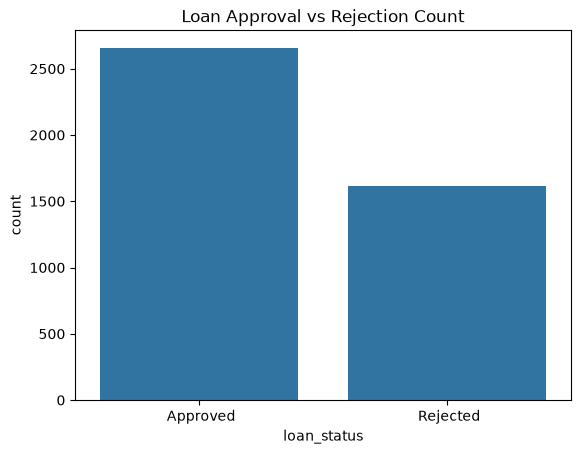

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df, x='loan_status')
plt.title('Loan Approval vs Rejection Count')
plt.show()

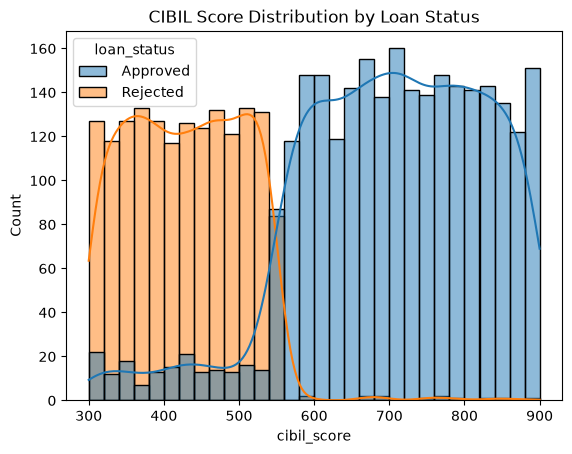

In [13]:
sns.histplot(data=df, x='cibil_score', hue='loan_status', bins=30, kde=True)
plt.title('CIBIL Score Distribution by Loan Status')
plt.show()

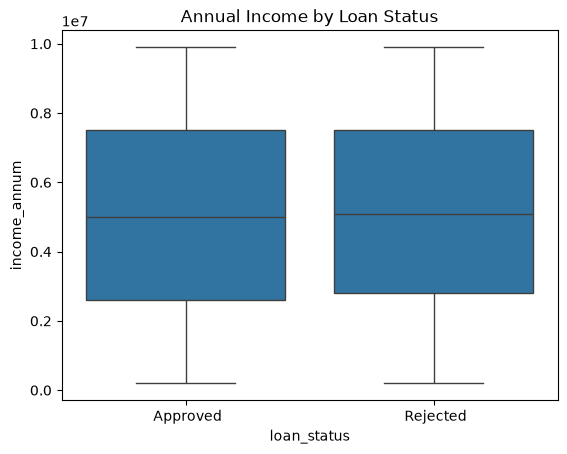

In [14]:
sns.boxplot(data=df, x='loan_status', y='income_annum')
plt.title('Annual Income by Loan Status')
plt.show()


In [16]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [19]:
print('education:', df['education'].unique())
print('self_employed:', df['self_employed'].unique())
print('loan_status:', df['loan_status'].unique())

education: <StringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str
self_employed: <StringArray>
[' No', ' Yes']
Length: 2, dtype: str
loan_status: <StringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str


In [20]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

C:\Users\HP\AppData\Local\Temp\ipykernel_14016\3446267575.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [21]:
df['education'] = df['education'].map({'Graduate': 1, 'Not Graduate': 0})
df['self_employed'] = df['self_employed'].map({'Yes': 1, 'No': 0})
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

In [22]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [23]:
df['total_assets_value'] = (
    df['residential_assets_value']
    + df['commercial_assets_value']
    + df['luxury_assets_value']
    + df['bank_asset_value']
)
df['debt_to_income_ratio'] = df['loan_amount'] / df['income_annum']

df[['total_assets_value', 'debt_to_income_ratio']].head()

,total_assets_value,debt_to_income_ratio
0,50700000,3.114583
1,17000000,2.975610
2,57700000,3.263736
3,52700000,3.743902
4,55000000,2.469388


In [24]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['loan_id', 'loan_status'])
y = df['loan_status']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (3415, 13)
X_test shape: (854, 13)
y_train shape: (3415,)
y_test shape: (854,)


In [28]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
  

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

In [30]:
print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', y_train_balanced.value_counts().to_dict())

Before SMOTE: {1: 2120, 0: 1295}
After SMOTE: {1: 2120, 0: 2120}


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [32]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_balanced, y_train_balanced)
y_pred_log = log_reg.predict(X_test_scaled)

In [33]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_balanced, y_train_balanced)
y_pred_knn = knn.predict(X_test_scaled)

In [34]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_balanced, y_train_balanced)
y_pred_dt = dt.predict(X_test_scaled)

In [35]:
svm = SVC(random_state=42)
svm.fit(X_train_balanced, y_train_balanced)
y_pred_svm = svm.predict(X_test_scaled)

In [36]:
nb = GaussianNB()
nb.fit(X_train_balanced, y_train_balanced)
y_pred_nb = nb.predict(X_test_scaled)

In [37]:
def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_pred)
    }

In [38]:
results = []
results.append(evaluate_model('Logistic Regression', y_test, y_pred_log))
results.append(evaluate_model('KNN', y_test, y_pred_knn))
results.append(evaluate_model('Decision Tree', y_test, y_pred_dt))
results.append(evaluate_model('SVM', y_test, y_pred_svm))
results.append(evaluate_model('Naive Bayes', y_test, y_pred_nb))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.914520,0.958416,0.902985,0.929875,0.918474
1,KNN,0.877049,0.949896,0.848881,0.896552,0.886704
2,Decision Tree,0.992974,0.998120,0.990672,0.994382,0.993763
3,SVM,0.934426,0.966926,0.927239,0.946667,0.936890
4,Naive Bayes,0.932084,0.983806,0.906716,0.943689,0.940780


In [39]:
from sklearn.model_selection import cross_val_score

dt_cv_scores = cross_val_score(dt, X_train_balanced, y_train_balanced, cv=5)
print('Decision Tree CV scores:', dt_cv_scores)
print('Average:', dt_cv_scores.mean())

Decision Tree CV scores: [0.99528302 0.98938679 0.99528302 0.99292453 0.99292453]
Average: 0.9931603773584907


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_balanced, y_train_balanced)
y_pred_rf = rf.predict(X_test_scaled)

In [41]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_balanced, y_train_balanced)
y_pred_gb = gb.predict(X_test_scaled)

In [42]:
results.append(evaluate_model('Random Forest', y_test, y_pred_rf))
results.append(evaluate_model('Gradient Boosting', y_test, y_pred_gb))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.914520,0.958416,0.902985,0.929875,0.918474
1,KNN,0.877049,0.949896,0.848881,0.896552,0.886704
2,Decision Tree,0.992974,0.998120,0.990672,0.994382,0.993763
3,SVM,0.934426,0.966926,0.927239,0.946667,0.936890
4,Naive Bayes,0.932084,0.983806,0.906716,0.943689,0.940780
5,Random Forest,0.998829,0.998138,1.000000,0.999068,0.998428
6,Gradient Boosting,0.997658,0.998134,0.998134,0.998134,0.997495


In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_balanced, y_train_balanced)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Control

In [44]:
print('Best parameters:', grid_search.best_params_)
print('Best cross-validation score:', grid_search.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score: 0.9945755267064468


In [45]:
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_scaled)

In [46]:
results.append(evaluate_model('Random Forest (Tuned)', y_test, y_pred_best_rf))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.914520,0.958416,0.902985,0.929875,0.918474
1,KNN,0.877049,0.949896,0.848881,0.896552,0.886704
2,Decision Tree,0.992974,0.998120,0.990672,0.994382,0.993763
3,SVM,0.934426,0.966926,0.927239,0.946667,0.936890
4,Naive Bayes,0.932084,0.983806,0.906716,0.943689,0.940780
5,Random Forest,0.998829,0.998138,1.000000,0.999068,0.998428
6,Gradient Boosting,0.997658,0.998134,0.998134,0.998134,0.997495
7,Random Forest (Tuned),0.998829,0.998138,1.000000,0.999068,0.998428


In [47]:
import joblib

joblib.dump(best_rf, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

X_train_balanced_df = pd.DataFrame(X_train_balanced, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_balanced_df.to_csv('X_train_balanced.csv', index=False)
X_test_scaled_df.to_csv('X_test_scaled.csv', index=False)
y_train_balanced.to_csv('y_train_balanced.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(max_depth=10, n_estimators=100, random_state=42))
])

final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['no_of_dependents','education','self_employed',...,'bank_asset_value', 'total_assets_value','debt_to_income_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [49]:
from sklearn.model_selection import cross_val_score

pipeline_scores = cross_val_score(final_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print('Pipeline CV scores:', pipeline_scores)
print('Average:', pipeline_scores.mean())

Pipeline CV scores: [0.99560761 0.99560761 0.99414348 0.99560761 0.99707174]
Average: 0.9956076134699854


In [50]:
import joblib

joblib.dump(final_pipeline, 'final_pipeline.pkl')
print('Final pipeline saved')

Final pipeline saved
